In [1]:
from mpasviewer import scvtmesh
from earthcmap import escmap

In [2]:
path2data = 'sample_data'

mpasd = scvtmesh(grid_file=f'{path2data}/WOFS/wofs_gsl.invariant.nc', 
                 diag_list=f'{path2data}/WOFS/wofs_gsl_01.diag.2024-05-08_19.15.00.nc')

In [ ]:
mpasd.dataset()

In [5]:
dta = mpasd.load()

In [7]:
dta

<xarray.Dataset> Size: 168MB
Dimensions:                      (node: 231611, edge: 346743, face: 115133,
                                  time: 1, nVertLevels: 59, nmax_face: 10)
Coordinates:
    node_x                       (node) float32 926kB -95.05 -95.02 ... -84.71
    node_y                       (node) float32 926kB 31.86 31.85 ... 40.34
    edge_x                       (edge) float32 1MB -95.0 -94.94 ... -84.75
    edge_y                       (edge) float32 1MB 31.86 31.86 ... 40.36 40.36
    face_x                       (face) float32 461kB -95.04 -95.01 ... -84.75
    face_y                       (face) float32 461kB 31.87 31.86 ... 40.35
  * time                         (time) datetime64[ns] 8B 2024-05-08T19:15:00
  * nVertLevels                  (nVertLevels) int64 472B 0 1 2 3 ... 56 57 58
Dimensions without coordinates: node, edge, face, nmax_face
Data variables: (12/46)
    mesh2d                       int64 8B 0
    projected_coordinate_system  int64 8B 0
    face_nodes                   (face, nmax_face) int64 9MB 524 525 0 ... -1 -1
    snowncv                      (time, face) float32 461kB 0.0 0.0 ... 0.0 0.0
    rainncv                      (time, face) float32 461kB 3.366e-06 ... 0.0
    graupelncv                   (time, face) float32 461kB 0.0 0.0 ... 0.0 0.0
    ...                           ...
    tend_sfc_pressure            (time, face) float32 461kB -0.03867 ... 0.00...
    refl10cm                     (time, nVertLevels, face) float32 27MB 0.0 ....
    divergence                   (time, nVertLevels, face) float32 27MB -0.00...
    pressure_p                   (time, nVertLevels, face) float32 27MB 555.3...
    h_divergence                 (time, nVertLevels, face) float32 27MB -0.00...
    ke                           (time, nVertLevels, face) float32 27MB 7.532...
Attributes:
    Conventions:      CF-1.12 UGRID-1.0
    model_name:       MPAS
    core_name:        Atmosphere
    source:           MPAS-A
    source_software:  MPAS-viewer
    date_created:     2026-02-18 23:54:23Z
    date_modified:    2026-02-18 23:54:23Z

In [6]:
times = [str(x) for x in dta['time'].data.astype('datetime64[s]')]
# print(*times, sep = ", ")

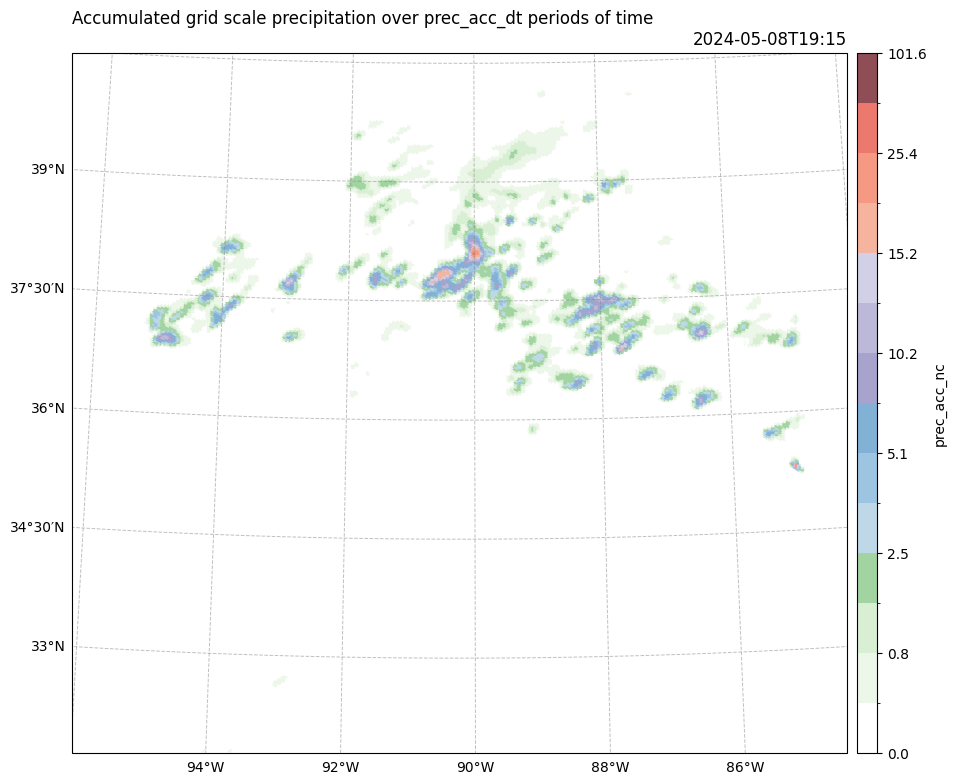

In [7]:
var1 = 'prec_acc_nc'
cmap, norm = escmap("wofs_prec", units=dta[var1].attrs['units'])
mpasd.show(dta, var_name = var1, cmap = cmap, norm = norm, figsize = (10, 10))

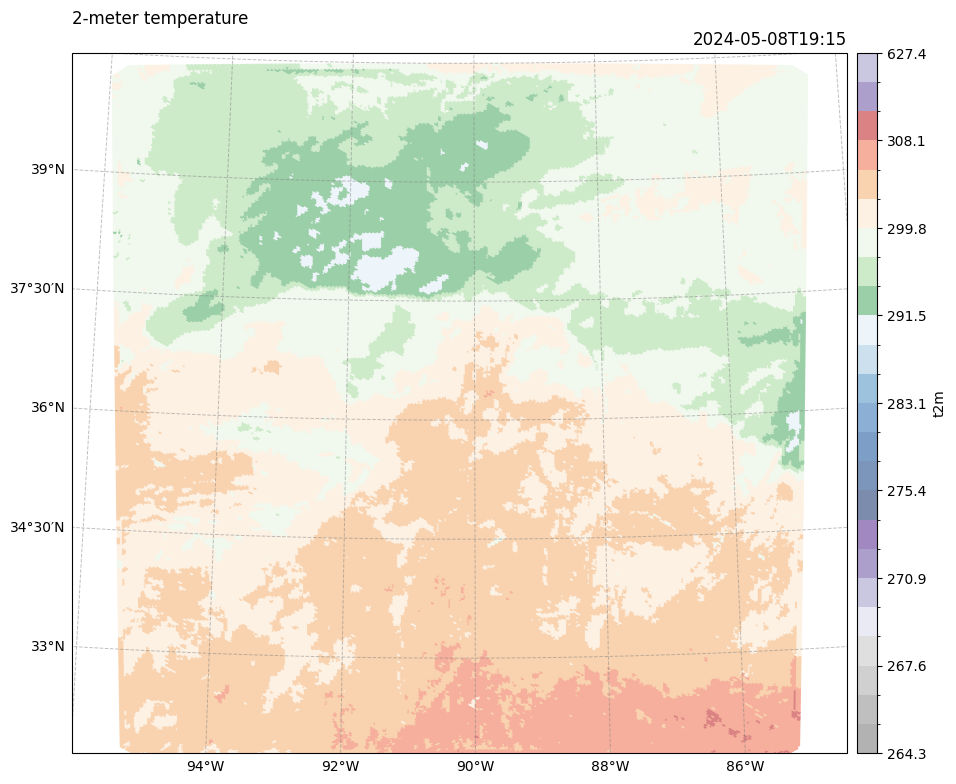

In [6]:
var2 = 't2m'
cmap, norm = escmap("temp_wofs", units=dta[var2].attrs['units'])
mpasd.show(dta, var_name = var2, cmap = cmap, norm = norm, figsize = (10, 10))

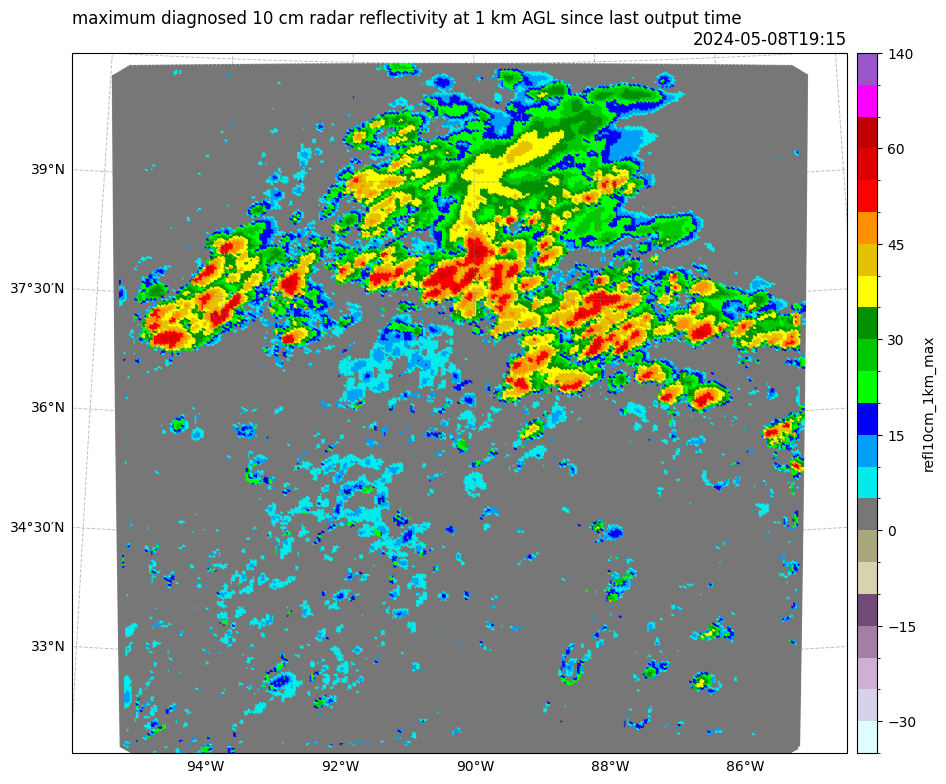

In [13]:
var3 = 'refl10cm_1km_max'
cmap, norm = escmap("mrms_cref", units=dta[var3].attrs['units'])
mpasd.show(dta, var_name = var3, cmap = cmap, norm = norm, figsize = (10, 10))

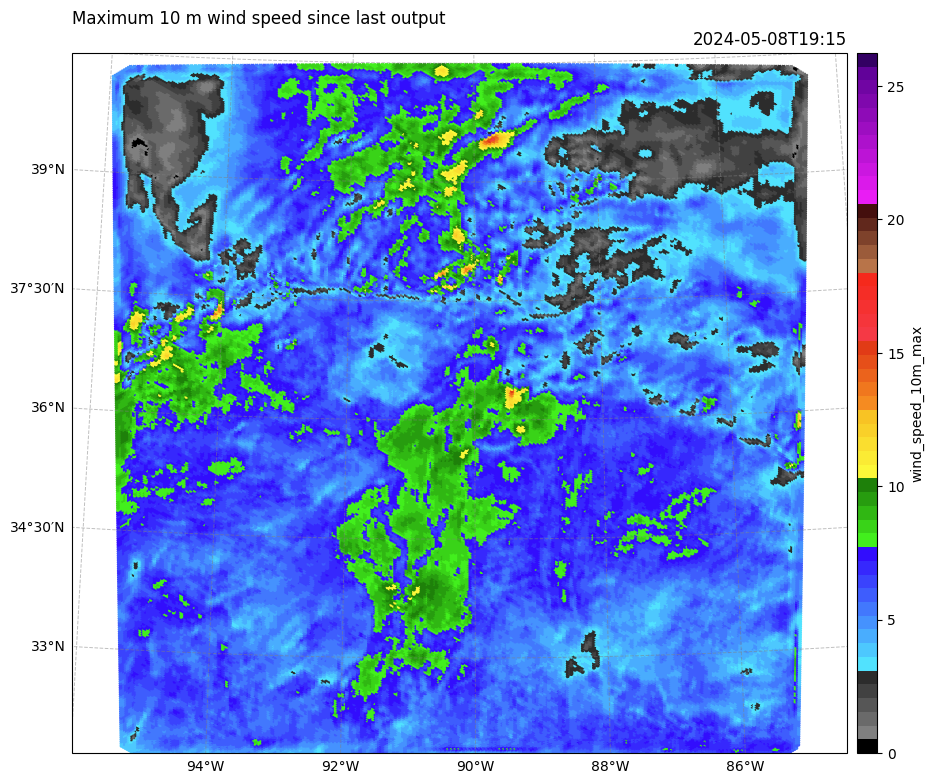

In [15]:
var4 = 'wind_speed_10m_max'
cmap, norm = escmap("wind_quikscat", units=dta[var4].attrs['units'])
mpasd.show(dta, var_name = var4, cmap = cmap, norm = norm, figsize = (10, 10))

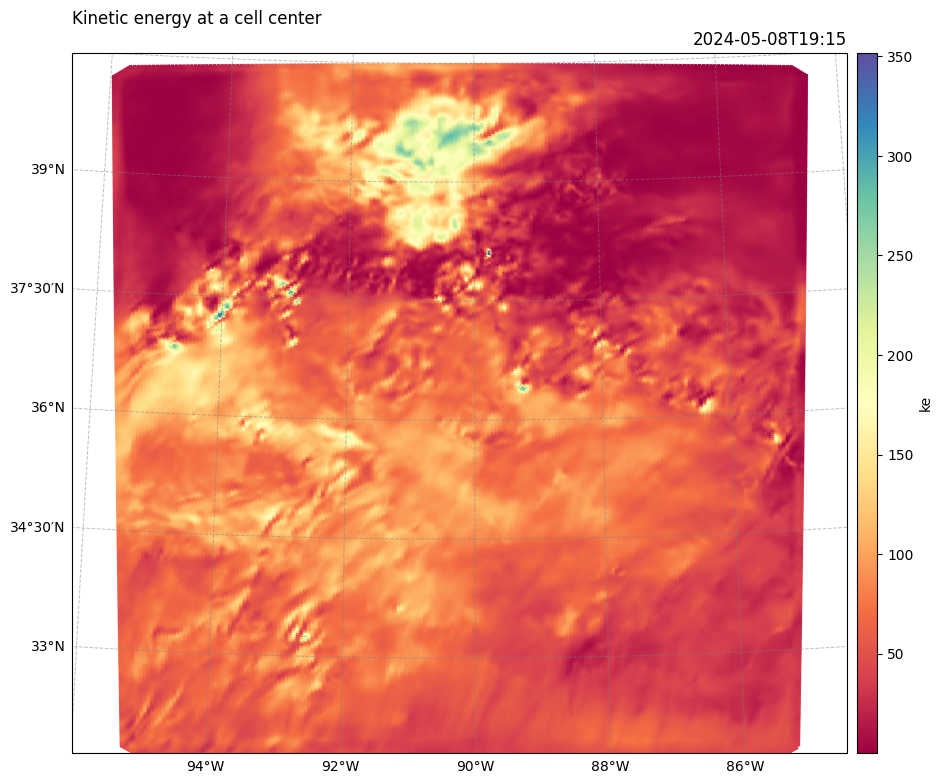

In [17]:
var5 = 'ke'
mpasd.show(dta, var_name = var5, level = 15, figsize = (10, 10))